# 第 01 章　機器學習簡介與環境安裝

這是「醫學生的機器學習入門」第 01 章的配套 notebook。

- **在 Colab 執行**：上方選單「執行階段 → 全部執行」即可，不需要安裝任何東西。本章只用 Colab 內建的套件與 scikit-learn 內建資料集，不需要網路下載資料。
- **在自己電腦執行**：需要 Python 3.10 以上，以及 numpy、pandas、matplotlib、scikit-learn（安裝方式見網站第 01 章「環境安裝」一節）。
- 由上往下一格一格執行（Shift + Enter）。每一格程式碼前都有一段說明。

> 本章使用 Breast Cancer Wisconsin (Diagnostic) 資料集（CC BY 4.0），僅供學習，不構成臨床建議。

## 0. 確認環境

先印出 Python 與主要套件的版本。之後遇到錯誤、上網查解法時，版本號是第一個要核對的資訊。

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib
import sklearn

print("Python      ", sys.version.split()[0])
print("numpy       ", np.__version__)
print("pandas      ", pd.__version__)
print("matplotlib  ", matplotlib.__version__)
print("scikit-learn", sklearn.__version__)

Python       3.12.2
numpy        2.1.3
pandas       2.2.3
matplotlib   3.10.0
scikit-learn 1.6.1


## 1. 載入資料：WDBC 乳癌細針抽吸資料

scikit-learn 內建這份資料，一行就能載入，不需要網路。每一列是一位病人的乳房腫塊細針抽吸（fine-needle aspiration）影像，30 個欄位是電腦從細胞核影像量出來的數值（半徑、紋理、周長、面積、凹點……），答案欄 `target` 是病理診斷。

In [2]:
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer(as_frame=True)
df = data.frame

print("資料大小（列, 欄）:", df.shape)
print("target 的意義:", dict(enumerate(data.target_names.tolist())))
print(df["target"].value_counts().rename(index=dict(enumerate(data.target_names.tolist()))))

資料大小（列, 欄）: (569, 31)
target 的意義: {0: 'malignant', 1: 'benign'}
target
benign       357
malignant    212
Name: count, dtype: int64


注意：scikit-learn 版本的編碼是 **0 = malignant（惡性）、1 = benign（良性）**，跟直覺的「1 = 有病」相反。之後算敏感度時要特別小心。

看看前五列長什麼樣子：

In [3]:
df.iloc[:5, [0, 1, 2, 3, 7, -1]]

,mean radius,mean texture,mean perimeter,mean area,mean concave points,target
0,17.99,10.38,122.80,1001.0,0.14710,0
1,20.57,17.77,132.90,1326.0,0.07017,0
2,19.69,21.25,130.00,1203.0,0.12790,0
3,11.42,20.38,77.58,386.1,0.10520,0
4,20.29,14.34,135.10,1297.0,0.10430,0


## 2. 五行程式跑出第一個模型

切出 25% 當「期末考」（測試集），用剩下 75% 訓練一棵決策樹，最後在沒看過的測試集上打分數。

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

X, y = load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)
model = DecisionTreeClassifier(max_depth=3, random_state=42)
model.fit(X_train, y_train)
print("測試集準確率:", round(model.score(X_test, y_test), 3))

測試集準確率: 0.944


輸出的數字是「測試集中有幾成病人被判對」。`random_state=42` 固定了隨機切分，讓你每次跑的結果都一樣。

## 3. 訓練分數 vs 測試分數

同一個模型分別在「看過的題目」和「沒看過的題目」上打分數，比較兩者差多少。

In [5]:
print("訓練集準確率:", round(model.score(X_train, y_train), 3))
print("測試集準確率:", round(model.score(X_test, y_test), 3))
print("訓練集人數:", len(y_train), "／ 測試集人數:", len(y_test))

訓練集準確率: 0.977
測試集準確率: 0.944
訓練集人數: 426 ／ 測試集人數: 143


訓練集分數比測試集高是常態；兩者差距愈大，代表模型愈可能只是「背答案」。

## 4. 換成醫學語言：混淆矩陣、敏感度、特異度

準確率把所有錯誤一視同仁，但臨床上「把惡性判成良性」（偽陰性）的代價遠比反過來嚴重。我們把惡性（0）當作陽性，算出熟悉的敏感度與特異度。

In [6]:
import pandas as pd
from sklearn.metrics import confusion_matrix

y_pred = model.predict(X_test)
cm = confusion_matrix(y_test, y_pred, labels=[0, 1])   # 列 = 真實，欄 = 預測；順序 [惡性, 良性]
print(pd.DataFrame(cm,
                   index=["真實：惡性", "真實：良性"],
                   columns=["預測：惡性", "預測：良性"]))

sensitivity = cm[0, 0] / cm[0].sum()   # 惡性中被抓到的比例
specificity = cm[1, 1] / cm[1].sum()   # 良性中被正確排除的比例
print("\n敏感度 (sensitivity):", round(sensitivity, 3))
print("特異度 (specificity):", round(specificity, 3))

       預測：惡性  預測：良性
真實：惡性     48      5
真實：良性      3     87

敏感度 (sensitivity): 0.906
特異度 (specificity): 0.967


右上角那格就是偽陰性：真的惡性、模型卻說良性的人數。第 11 章會再談怎麼調整閾值來換取更高的敏感度。

## 5. 過擬合：模型愈複雜一定愈好嗎？

把決策樹的最大深度從 1 調到 15，分別記錄訓練集與測試集的準確率，畫成折線圖。（圖上標籤用英文，因為 Colab 預設沒有中文字型。）

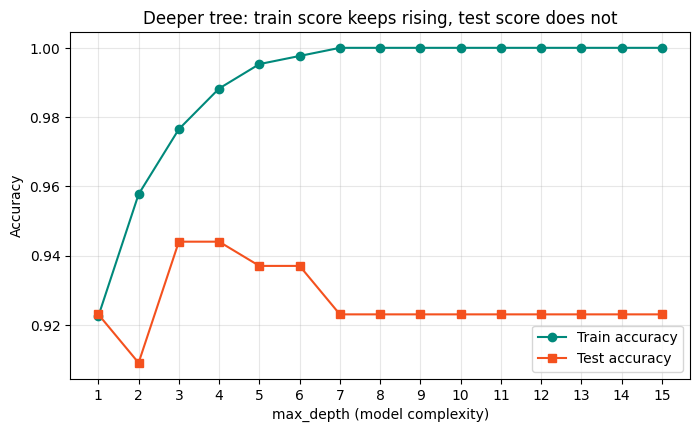

depth= 1  train=0.923  test=0.923
depth= 2  train=0.958  test=0.909
depth= 3  train=0.977  test=0.944
depth= 4  train=0.988  test=0.944
depth= 5  train=0.995  test=0.937
depth= 6  train=0.998  test=0.937
depth= 7  train=1.000  test=0.923
depth= 8  train=1.000  test=0.923
depth= 9  train=1.000  test=0.923
depth=10  train=1.000  test=0.923
depth=11  train=1.000  test=0.923
depth=12  train=1.000  test=0.923
depth=13  train=1.000  test=0.923
depth=14  train=1.000  test=0.923
depth=15  train=1.000  test=0.923


In [7]:
import matplotlib.pyplot as plt

depths = range(1, 16)
train_acc, test_acc = [], []
for d in depths:
    m = DecisionTreeClassifier(max_depth=d, random_state=42).fit(X_train, y_train)
    train_acc.append(m.score(X_train, y_train))
    test_acc.append(m.score(X_test, y_test))

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(depths, train_acc, "o-", color="#00897B", label="Train accuracy")
ax.plot(depths, test_acc, "s-", color="#F4511E", label="Test accuracy")
ax.set_xlabel("max_depth (model complexity)")
ax.set_ylabel("Accuracy")
ax.set_title("Deeper tree: train score keeps rising, test score does not")
ax.set_xticks(list(depths))
ax.grid(alpha=0.3)
ax.legend()
plt.show()

for d, a, b in zip(depths, train_acc, test_acc):
    print(f"depth={d:2d}  train={a:.3f}  test={b:.3f}")

深度 7 以後訓練集已經滿分，測試集卻停在比深度 3、4 還低的位置——這就是過擬合的樣子：模型把訓練資料的雜訊也一起背了下來。

## 6. 同一份資料，換成你熟悉的邏輯迴歸

流行病學課上的 logistic regression，在機器學習裡也是一個分類模型。先把各欄位標準化（z 分數），再訓練邏輯迴歸。

In [8]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

logit = make_pipeline(StandardScaler(), LogisticRegression(solver="liblinear"))
logit.fit(X_train, y_train)
print("邏輯迴歸 訓練集準確率:", round(logit.score(X_train, y_train), 3))
print("邏輯迴歸 測試集準確率:", round(logit.score(X_test, y_test), 3))

邏輯迴歸 訓練集準確率: 0.988
邏輯迴歸 測試集準確率: 0.986


在這一次切分下邏輯迴歸的測試分數比決策樹高，但只憑一次切分、一百多位測試病人，還不能下「邏輯迴歸比較好」的結論；第 11 章會用交叉驗證更公平地比較。

## 動手試試

1. 把第 2 節的 `random_state=42` 改成 `0` 或 `7` 再跑一次，測試集準確率會變多少？這告訴你「單一次切分的分數」有多不穩定。
2. 把第 2 節的 `max_depth=3` 改成 `None`（不限制深度），比較訓練集與測試集準確率的差距。
3. 把 `test_size=0.25` 改成 `0.5`（訓練資料變少），第 5 節的兩條線會怎麼變化？